In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, GridSearchCV, cross_val_predict, StratifiedKFold
import xgboost as xgb
import mlflow


In [271]:
user_features = pd.read_csv('user_features.csv')
data = np.load('data/training_batch_with_labels.npz')
raw_data = data["X"]
labels=data["y"]
user_features = user_features.drop(labels=['Unnamed: 0'], axis=1)
df=pd.DataFrame(raw_data)
labels=pd.DataFrame(labels)
df.columns = ["user", "item", "rating"]
user_features

,user,user_mean_rating,user_rating_std,user_min_rating,user_max_rating,num_ratings,item_coverage,rating_0.0_%,rating_1.0_%,rating_2.0_%,rating_3.0_%,rating_4.0_%,rating_5.0_%,label,rating_entropy,extreme_rating_ratio,rating_skew,rating_kurtosis,rating_mad
0,100,3.147727,1.169928,0.0,5.0,88,0.088,0.045455,0.056818,0.102273,0.363636,0.363636,0.068182,0,1.455461,0.0,-0.955265,0.852420,0.872417
1,101,3.406926,0.854016,0.0,5.0,231,0.231,0.008658,0.017316,0.051948,0.489177,0.346320,0.086580,0,1.193838,0.0,-0.551682,1.931539,0.686644
2,102,3.673469,1.072385,1.0,5.0,98,0.098,0.000000,0.061224,0.081633,0.173469,0.489796,0.193878,0,1.347083,0.0,-0.949902,0.488450,0.834236
3,103,3.000000,1.290994,0.0,5.0,103,0.103,0.058252,0.097087,0.116505,0.310680,0.349515,0.067961,0,1.555827,0.0,-0.752762,-0.073219,0.970874
4,104,3.719101,0.988442,1.0,5.0,89,0.089,0.000000,0.044944,0.011236,0.359551,0.348315,0.235955,0,1.265745,0.0,-0.632862,0.624917,0.800151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,1195,3.850000,0.745160,3.0,5.0,20,0.020,0.000000,0.000000,0.000000,0.350000,0.450000,0.200000,0,1.048654,0.0,0.256526,-1.042813,0.595000
1096,1196,2.930976,0.563311,0.0,5.0,594,0.594,0.001684,0.006734,0.161616,0.722222,0.104377,0.003367,0,0.829041,0.0,-0.358195,2.384301,0.336797
1097,1197,3.600000,1.837873,0.0,5.0,10,0.010,0.100000,0.100000,0.000000,0.200000,0.100000,0.500000,0,1.359237,0.0,-1.138330,0.120758,1.480000
1098,1198,3.160121,0.666319,1.0,5.0,331,0.331,0.000000,0.012085,0.096677,0.631420,0.238671,0.021148,0,0.993042,0.0,-0.007611,1.116689,0.478729


In [ ]:
# -----------------------------------------
# Base user feature dataset
# -----------------------------------------

X = user_features.drop(columns=["user", "label"])
y = user_features["label"]

print(X.shape, y.shape)

# -----------------------------------------
# MLflow setup
# -----------------------------------------

mlflow.set_tracking_uri("http://127.0.0.1:5001/")
mlflow.xgboost.autolog()

# -----------------------------------------
# Cross validation
# -----------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# -----------------------------------------
# Manual hyperparameters
# -----------------------------------------

params = dict(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=13,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=1
)

# store out-of-fold predictions
all_probs = np.zeros(len(X))
all_labels = y.values

# -----------------------------------------
# Training
# -----------------------------------------

with mlflow.start_run(experiment_id=1, tags={"version": "manual_tuning"}):

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

        print(f"Training fold {fold}")

        # -----------------------------------------
        # Identify users for this fold
        # -----------------------------------------

        train_users = user_features.iloc[train_idx]["user"].values
        val_users = user_features.iloc[val_idx]["user"].values

        # interaction split
        train_df = df[df["user"].isin(train_users)].copy()
        val_df = df[df["user"].isin(val_users)].copy()

        # -----------------------------------------
        # Compute item mean (TRAIN ONLY)
        # -----------------------------------------

        item_mean = train_df.groupby("item")["rating"].mean()

        train_df["item_mean"] = train_df["item"].map(item_mean)
        val_df["item_mean"] = val_df["item"].map(item_mean)

        global_mean = train_df["rating"].mean()

        val_df["item_mean"] = val_df["item_mean"].fillna(global_mean)

        # -----------------------------------------
        # Residual computation
        # -----------------------------------------

        train_df["rating_residual"] = train_df["rating"] - train_df["item_mean"]
        val_df["rating_residual"] = val_df["rating"] - val_df["item_mean"]

        # -----------------------------------------
        # Residual features
        # -----------------------------------------

        train_residual = train_df.groupby("user")["rating_residual"].agg(
            ["mean", "std", "max", "min"]
        ).rename(columns={
            "mean": "avg_rating_residual",
            "std": "std_rating_residual",
            "max": "max_rating_residual",
            "min": "min_rating_residual"
        })

        val_residual = val_df.groupby("user")["rating_residual"].agg(
            ["mean", "std", "max", "min"]
        ).rename(columns={
            "mean": "avg_rating_residual",
            "std": "std_rating_residual",
            "max": "max_rating_residual",
            "min": "min_rating_residual"
        })

        # -----------------------------------------
        # Strong disagreement feature
        # -----------------------------------------

        train_df["strong_disagreement"] = np.abs(train_df["rating_residual"]) > 2
        val_df["strong_disagreement"] = np.abs(val_df["rating_residual"]) > 2

        train_disagreement = (
            train_df.groupby("user")["strong_disagreement"]
            .mean()
            .rename("strong_disagreement_ratio")
        )

        val_disagreement = (
            val_df.groupby("user")["strong_disagreement"]
            .mean()
            .rename("strong_disagreement_ratio")
        )

        # -----------------------------------------
        # Unique rating count feature
        # -----------------------------------------

        train_unique_ratings = (
            train_df.groupby("user")["rating"]
            .nunique()
            .rename("unique_ratings_used")
        )

        val_unique_ratings = (
            val_df.groupby("user")["rating"]
            .nunique()
            .rename("unique_ratings_used")
        )

        # -----------------------------------------
        # Rating concentration feature
        # -----------------------------------------

        train_rating_dist = pd.crosstab(train_df["user"], train_df["rating"])
        val_rating_dist = pd.crosstab(val_df["user"], val_df["rating"])

        train_p = train_rating_dist.div(train_rating_dist.sum(axis=1), axis=0)
        val_p = val_rating_dist.div(val_rating_dist.sum(axis=1), axis=0)

        train_concentration = train_p.max(axis=1).rename("rating_concentration")
        val_concentration = val_p.max(axis=1).rename("rating_concentration")

        # -----------------------------------------
        # Base feature split
        # -----------------------------------------

        X_train = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()

        # -----------------------------------------
        # Merge fold features
        # -----------------------------------------

        X_train = X_train.merge(train_residual, left_index=True, right_index=True, how="left")
        X_val = X_val.merge(val_residual, left_index=True, right_index=True, how="left")

        X_train = X_train.merge(train_disagreement, left_index=True, right_index=True, how="left")
        X_val = X_val.merge(val_disagreement, left_index=True, right_index=True, how="left")

        X_train = X_train.merge(train_unique_ratings, left_index=True, right_index=True, how="left")
        X_val = X_val.merge(val_unique_ratings, left_index=True, right_index=True, how="left")

        X_train = X_train.merge(train_concentration, left_index=True, right_index=True, how="left")
        X_val = X_val.merge(val_concentration, left_index=True, right_index=True, how="left")

        # replace missing values
        X_train = X_train.fillna(0)
        X_val = X_val.fillna(0)

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        # -----------------------------------------
        # Train model
        # -----------------------------------------

        model = xgb.XGBClassifier(**params)

        model.fit(X_train, y_train)

        # validation probabilities
        y_prob = model.predict_proba(X_val)[:, 1]

        all_probs[val_idx] = y_prob
        all_probs[val_idx] = y_prob

        # ---- fold metrics ----
        fold_roc = roc_auc_score(y_val, y_prob)
        fold_prc = average_precision_score(y_val, y_prob)

        print(f"Fold {fold} ROC-AUC: {fold_roc:.4f}")
        print(f"Fold {fold} AUPRC : {fold_prc:.4f}")
        print("-"*40)
        
        

    # -----------------------------------------
    # Evaluation
    # -----------------------------------------

    roc = roc_auc_score(all_labels, all_probs)
    prc = average_precision_score(all_labels, all_probs)

    print("ROC-AUC:", roc)
    print("AUPRC:", prc)

    # -----------------------------------------
    # Threshold tuning
    # -----------------------------------------
    precision_curve, recall_curve, thresholds_curve = precision_recall_curve(all_labels, all_probs)
    
    # Calculate F1 score (beta=2 means recall is 2x more important)
    beta = 1
    f_beta_scores = ((1 + beta**2) * precision * recall) / (beta**2 * precision + recall + 1e-10)

    # Find best F2
    best_idx = np.argmax(f_beta_scores)
    best_threshold = thresholds[best_idx]

    print("best threshold:", best_threshold)

    mlflow.log_metric("roc_auc", roc)
    mlflow.log_metric("auprc", prc)
    mlflow.log_metric("best_threshold", best_threshold)

# -----------------------------------------
# Feature importance
# -----------------------------------------

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

(1100, 17) (1100,)
Training fold 0


2026/03/16 21:27:26 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/Kathir/Documents/Coursework/machine_learning/ml_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/16 21:27:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/0

Fold 0 ROC-AUC: 0.8340
Fold 0 AUPRC : 0.5775
----------------------------------------
Training fold 1


2026/03/16 21:27:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/Kathir/Documents/Coursework/machine_learning/ml_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/16 21:27:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/0

Fold 1 ROC-AUC: 0.7905
Fold 1 AUPRC : 0.5512
----------------------------------------
Training fold 2


...

Fold 2 ROC-AUC: 0.9085
Fold 2 AUPRC : 0.7709
----------------------------------------
Training fold 3


2026/03/16 21:27:34 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/Kathir/Documents/Coursework/machine_learning/ml_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/16 21:27:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/0

Fold 3 ROC-AUC: 0.8222
Fold 3 AUPRC : 0.6298
----------------------------------------
Training fold 4


2026/03/16 21:27:36 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/Kathir/Documents/Coursework/machine_learning/ml_env/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/16 21:27:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/0

Fold 4 ROC-AUC: 0.8130
Fold 4 AUPRC : 0.6433
----------------------------------------
ROC-AUC: 0.83666
AUPRC: 0.6273584267629349
best threshold: 0.9680126905441284
🏃 View run welcoming-donkey-446 at: http://127.0.0.1:5001/#/experiments/1/runs/719094b120c64324b9bf6d3198b1f394
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
rating_1.0_%                 0.230954
user_min_rating              0.151562
rating_entropy               0.084452
user_rating_std              0.060219
rating_skew                  0.053737
rating_kurtosis              0.042551
rating_2.0_%                 0.037277
num_ratings                  0.037125
user_mean_rating             0.036585
rating_5.0_%                 0.033057
std_rating_residual          0.032258
rating_4.0_%                 0.032064
max_rating_residual          0.029437
rating_concentration         0.029410
strong_disagreement_ratio    0.025986
rating_3.0_%                 0.023137
avg_rating_residual          0.022644
min_rating_residua

In [367]:
# convert probabilities to predictions using chosen threshold
y_pred = (all_probs >= best_threshold).astype(int)

# confusion matrix
cm = confusion_matrix(all_labels, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Normal", "Actual Anomaly"],
    columns=["Predicted Normal", "Predicted Anomaly"]
)

print("Confusion Matrix:")
print(cm_df)

print("\nClassification Report:")
print(classification_report(all_labels, y_pred))


Confusion Matrix:
                Predicted Normal  Predicted Anomaly
Actual Normal                996                  4
Actual Anomaly                53                 47

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1000
           1       0.92      0.47      0.62       100

    accuracy                           0.95      1100
   macro avg       0.94      0.73      0.80      1100
weighted avg       0.95      0.95      0.94      1100



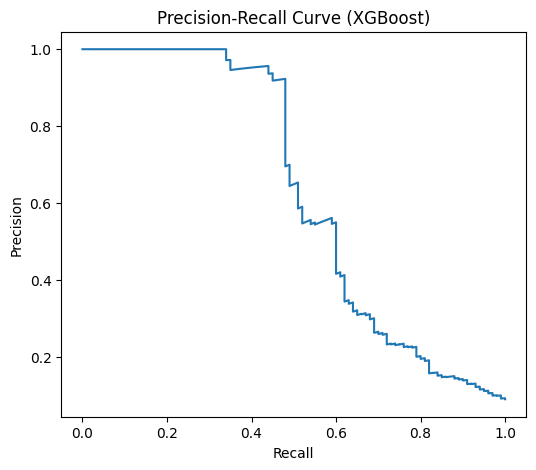

In [368]:
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost)")
plt.show()

In [369]:
model = xgb.XGBClassifier(**params)

X_full = X.copy()

# compute residual features using full df
item_mean_train = df.groupby("item")["rating"].mean()

df["item_mean"] = df["item"].map(item_mean_train)
df["rating_residual"] = df["rating"] - df["item_mean"]

residual_features = df.groupby("user")["rating_residual"].agg(
    ["mean","std","max","min"]
).rename(columns={
    "mean":"avg_rating_residual",
    "std":"std_rating_residual",
    "max":"max_rating_residual",
    "min":"min_rating_residual"
})

X_full = X_full.merge(residual_features, left_index=True, right_index=True, how="left")
X_full = X_full.fillna(0)

model.fit(X_full, y)

2026/03/16 21:28:25 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during xgboost autologging: INVALID_PARAMETER_VALUE: The experiment 3 must be in the 'active' state. Current state is deleted.


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [383]:
# Load test interactions
X_test = np.load('data/first_batch.npz')['X']

test_df = pd.DataFrame(
    X_test,
    columns=["user","item","rating"]
)

# Remove duplicate user-item ratings
test_df = (
    test_df
    .groupby(["user","item"])["rating"]
    .mean()
    .reset_index()
)

# ----------------------------
# User statistics
# ----------------------------

user_stats = test_df.groupby("user")["rating"].agg(
    ["mean","std","min","max","count"]
).rename(columns={
    "mean":"user_mean_rating",
    "std":"user_rating_std",
    "min":"user_min_rating",
    "max":"user_max_rating",
    "count":"num_ratings"
})

# ----------------------------
# Item coverage
# ----------------------------

items_per_user = test_df.groupby("user")["item"].nunique()

item_coverage = (items_per_user / 1000).rename("item_coverage")

# ----------------------------
# Rating distribution
# ----------------------------

rating_dist = pd.crosstab(test_df["user"], test_df["rating"])
rating_dist.columns = [f"rating_{c}_count" for c in rating_dist.columns]

# Convert to probabilities
p = rating_dist.div(rating_dist.sum(axis=1), axis=0)

# ----------------------------
# Rating entropy
# ----------------------------

rating_entropy = -(p * np.log(p + 1e-9)).sum(axis=1)
rating_entropy = rating_entropy.rename("rating_entropy")

# ----------------------------
# Residual features
# ----------------------------

# Use training item means
test_df["item_mean"] = test_df["item"].map(item_mean_train)

# Handle unseen items
global_mean = item_mean_train.mean()
test_df["item_mean"] = test_df["item_mean"].fillna(global_mean)

test_df["rating_residual"] = test_df["rating"] - test_df["item_mean"]

residual_features = test_df.groupby("user")["rating_residual"].agg(
    ["mean","std","max","min"]
).rename(columns={
    "mean":"avg_rating_residual",
    "std":"std_rating_residual",
    "max":"max_rating_residual",
    "min":"min_rating_residual"
})

# ----------------------------
# Combine user features
# ----------------------------

test_features = user_stats.join(item_coverage)
test_features = test_features.join(rating_dist)
test_features = test_features.join(rating_entropy)
test_features = test_features.join(residual_features)

test_features = test_features.fillna(0)

# ----------------------------
# Convert rating counts → %
# ----------------------------

rating_cols = [c for c in test_features.columns if "rating_" in c and "count" in c]

for col in rating_cols:
    
    pct_col = col.replace("_count","_%")
    
    test_features[pct_col] = (
        test_features[col] / test_features["num_ratings"].replace(0,1)
    )

test_features = test_features.drop(columns=rating_cols)

# ----------------------------
# Align with training feature order
# ----------------------------

test_features = test_features.reindex(
    columns=X_full.columns,
    fill_value=0
)

# ----------------------------
# Predict anomalies
# ----------------------------

test_probs = model.predict_proba(test_features)[:,1]

test_pred = (test_probs >= best_threshold).astype(int)

# ----------------------------
# Output ranking
# ----------------------------
results = pd.DataFrame({
    "user": test_features.index,
    "anomaly_score": test_probs,
    "prediction": test_pred
})

# results = results.sort_values(
#     "anomaly_score",
#     ascending=False
# )
print(results.shape)
results[results['prediction'] == 1].shape

samy = np.load('../submission.npz')
print(samy['predictions'])
np.savez('submission.npz', predictions=test_probs)
me = np.load('submission.npz')
print(me)
print(me['predictions'])

(1100, 3)
[0.09793546 0.11205474 0.05759774 ... 0.13593692 0.26779014 0.10777999]
NpzFile 'submission.npz' with keys: predictions
[0.03299521 0.0105934  0.00121037 ... 0.00028582 0.12182797 0.00290024]
